# The point forecast is useless

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/data-science-cookbook/prediction-interval/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=data-science-cookbook/prediction-interval/demo.ipynb)

A point forecast is a number. A 95% prediction interval is a **claim about a frequency** - and
a claim can be checked. Almost nobody checks it, partly because the check on a normal backtest
has almost no power, which is the last section of this notebook.

The process here is synthetic, so the frequency is measurable: draw 600 independent futures,
build the band on the history, and count.

**What is here**

1. Seven ways to build a band, and the frequency each one actually delivers
2. The sqrt(h) fan is an assumption about the MODEL, and it is two lines of numpy to check
3. The parameter-uncertainty term - free to include, and the difference between keeping the claim and not
4. Conformal's guarantee is MARGINAL, and nobody stands in the margin
5. Pointwise coverage is not path coverage
6. The check itself: why bad bands survive validation
7. Try your own

Sibling builds: [`forecast-backtest`](../forecast-backtest) (Day 172) scores the protocol that
produces a point error; [`calibration-checker`](../../ml-engineering-toolkit/calibration-checker)
does the classification-probability version of calibration.

## 1. Seven bands, and the frequency each delivers

The methods, in the order people reach for them: the textbook Gaussian band widened by
`sqrt(h)`; the same band **not** widened; the regression prediction interval that includes the
parameter-uncertainty term; empirical residual quantiles; quantiles of ACTUAL rolling h-step
errors; split conformal; and a residual bootstrap.

In [1]:
from __future__ import annotations
from typing import Callable, Dict, Optional, Tuple
import numpy as np
import matplotlib.pyplot as plt

PERIOD, H, CONF, N_TRAIN = 12, 12, 0.95, 168
Z = {0.80: 1.2815515655446004, 0.90: 1.6448536269514722,
     0.95: 1.959963984540054, 0.99: 2.5758293035489004}

def make_series(rng, n, level=100.0, trend=0.15, season_amp=8.0, period=PERIOD, sigma=4.0,
                rho=0.0, vol_period=None, vol_ratio=1.0, vol_phase=None):
    """Series plus the per-point noise sd that generated it.

    Regimes keep the AVERAGE VARIANCE at sigma^2: var_hi/var_lo = vol_ratio with
    var_hi = sigma^2 * 2r/(1+r). Multiplying and dividing sigma by sqrt(r) instead would be
    4.6x louder on average at r=9 - a test of more noise, not of the same noise unevenly spread.
    The block phase is drawn per series, or a fixed training length always forecasts into the
    same regime and the conditional split has an empty cell.
    """
    t = np.arange(n, dtype=float)
    signal = level + trend * t + season_amp * np.sin(2 * np.pi * t / period)
    if vol_period is None or vol_ratio == 1.0:
        sd = np.full(n, float(sigma))
    else:
        phase = int(rng.integers(0, 2 * vol_period)) if vol_phase is None else int(vol_phase)
        hi = ((t + phase) // vol_period).astype(int) % 2 == 1
        r = float(vol_ratio)
        sd = np.where(hi, sigma * np.sqrt(2 * r / (1 + r)), sigma * np.sqrt(2 / (1 + r)))
    if rho == 0.0:
        noise = rng.normal(0.0, 1.0, n) * sd
    else:
        e = rng.normal(0.0, np.sqrt(1 - rho ** 2), n)
        z = np.empty(n); z[0] = rng.normal(0.0, 1.0)
        for i in range(1, n):
            z[i] = rho * z[i - 1] + e[i]
        noise = z * sd
    return signal + noise, sd

def _cols(t, mu, sd, period):
    ts = (t - mu) / sd
    return np.column_stack([np.ones_like(ts), ts,
                            np.sin(2 * np.pi * t / period), np.cos(2 * np.pi * t / period)])

def fit_trend_season(y, period=PERIOD):
    n = len(y); t = np.arange(n, dtype=float)
    mu, sd = t.mean(), max(t.std(), 1e-9)
    X = _cols(t, mu, sd, period)
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    resid = y - X @ beta
    return {"beta": beta, "mu": mu, "sd": sd, "period": period, "n": n, "resid": resid,
            "s2": float(resid @ resid / max(n - X.shape[1], 1)),
            "XtXinv": np.linalg.pinv(X.T @ X)}

def predict(fit, h):
    t_out = np.arange(fit["n"], fit["n"] + h, dtype=float)
    return _cols(t_out, fit["mu"], fit["sd"], fit["period"]) @ fit["beta"]

def leverage(fit, h):
    t_out = np.arange(fit["n"], fit["n"] + h, dtype=float)
    X0 = _cols(t_out, fit["mu"], fit["sd"], fit["period"])
    return np.einsum("ij,jk,ik->i", X0, fit["XtXinv"], X0)

def _rolling_errors(y, h, k, min_train):
    last = len(y) - h
    ors = sorted(list(range(last, min_train - 1, -1))[:k])
    out = np.full((len(ors), h), np.nan)
    for i, o in enumerate(ors):
        pred = predict(fit_trend_season(y[:o]), h)
        act = y[o:o + h]
        out[i, :len(act)] = act - pred[:len(act)]
    return out

def gaussian_iid(y, h, conf=CONF, **kw):
    fit = fit_trend_season(y); p = predict(fit, h)
    w = Z[conf] * np.sqrt(fit["s2"]) * np.sqrt(np.arange(1, h + 1))
    return p - w, p + w

def gaussian_flat(y, h, conf=CONF, **kw):
    fit = fit_trend_season(y); p = predict(fit, h)
    w = np.full(h, Z[conf] * np.sqrt(fit["s2"]))
    return p - w, p + w

def gaussian_theory(y, h, conf=CONF, **kw):
    fit = fit_trend_season(y); p = predict(fit, h)
    w = Z[conf] * np.sqrt(fit["s2"] * (1.0 + leverage(fit, h)))
    return p - w, p + w

def empirical_residual(y, h, conf=CONF, **kw):
    fit = fit_trend_season(y); p = predict(fit, h); a = (1 - conf) / 2
    lo_q, hi_q = np.quantile(fit["resid"], [a, 1 - a])
    return p + lo_q, p + hi_q

def rolling_empirical(y, h, conf=CONF, k=30, min_train=96, **kw):
    fit = fit_trend_season(y); p = predict(fit, h)
    errs = _rolling_errors(y, h, k, min_train)
    if len(errs) < 4:
        return gaussian_iid(y, h, conf)
    a = (1 - conf) / 2
    lo = np.array([np.quantile(errs[:, j][~np.isnan(errs[:, j])], a) for j in range(h)])
    hi = np.array([np.quantile(errs[:, j][~np.isnan(errs[:, j])], 1 - a) for j in range(h)])
    return p + lo, p + hi

def split_conformal(y, h, conf=CONF, k=30, min_train=96, **kw):
    """The ceil((m+1)(1-alpha))/m index is what buys the finite-sample guarantee."""
    fit = fit_trend_season(y); p = predict(fit, h)
    errs = _rolling_errors(y, h, k, min_train)
    if len(errs) < 4:
        return gaussian_iid(y, h, conf)
    w = np.empty(h)
    for j in range(h):
        e = np.abs(errs[:, j][~np.isnan(errs[:, j])]); m = len(e)
        w[j] = np.quantile(e, min(1.0, np.ceil((m + 1) * conf) / m))
    return p - w, p + w

def bootstrap_path(y, h, conf=CONF, n_sim=400, seed=0, **kw):
    fit = fit_trend_season(y); p = predict(fit, h)
    draws = np.random.default_rng(seed).choice(fit["resid"], size=(n_sim, h), replace=True)
    a = (1 - conf) / 2
    return p + np.quantile(draws, a, axis=0), p + np.quantile(draws, 1 - a, axis=0)

METHODS = {"gaussian sqrt(h)": gaussian_iid, "gaussian flat": gaussian_flat,
           "gaussian + parameter term": gaussian_theory, "empirical residual": empirical_residual,
           "rolling h-step quantile": rolling_empirical, "split conformal": split_conformal,
           "bootstrap path": bootstrap_path}

def coverage_run(method, h, n_train, reps, rng, conf=CONF, **kw):
    hits = np.zeros((reps, h), dtype=bool); width = np.zeros((reps, h)); sd_at = np.zeros((reps, h))
    for i in range(reps):
        y, sd = make_series(rng, n_train + h, **kw)
        lo, hi = method(y[:n_train], h, conf)
        act = y[n_train:]
        hits[i] = (act >= lo) & (act <= hi); width[i] = hi - lo; sd_at[i] = sd[n_train:]
    return {"hits": hits, "width": width, "sd": sd_at}

runs = {n: coverage_run(m, H, N_TRAIN, 600, np.random.default_rng(5)) for n, m in METHODS.items()}
narrow = min(r["width"].mean() for r in runs.values())
print(f"{'method':<28}{'coverage':>10}{'at h=1':>9}{'at h=12':>9}{'width':>9}{'vs narrowest':>14}")
for n, r in runs.items():
    print(f"{n:<28}{r['hits'].mean():>10.3f}{r['hits'][:, 0].mean():>9.3f}"
          f"{r['hits'][:, -1].mean():>9.3f}{r['width'].mean():>9.2f}"
          f"{r['width'].mean() / narrow:>13.2f}x")

method                        coverage   at h=1  at h=12    width  vs narrowest
gaussian sqrt(h)                 0.994    0.945    1.000    38.13         2.71x
gaussian flat                    0.942    0.945    0.937    15.65         1.11x
gaussian + parameter term        0.948    0.948    0.943    15.94         1.13x
empirical residual               0.932    0.933    0.928    15.06         1.07x
rolling h-step quantile          0.897    0.908    0.888    14.07         1.00x
split conformal                  0.967    0.980    0.968    18.90         1.34x
bootstrap path                   0.932    0.937    0.927    15.25         1.08x


The band almost every forecast ships - residual sd widened by `sqrt(h)` - does not undercover.
It **overcovers**, at nearly three times the width of the narrowest honest band. A 95% interval
that is really a 99.4% interval is not a safe error: it is a band nobody can plan against, and
it will be quietly ignored.

## 2. The sqrt(h) fan is an assumption about the MODEL

Where does `sqrt(h)` come from? From a forecast whose h-step error is a **sum of h shocks** - a
random walk extrapolated by its last value. A fitted trend+season model makes a **direct**
h-step statement, and its error does not accumulate. Fitting the growth exponent on simulated
errors says which world you are in, before you ship anything.

In [2]:
rng = np.random.default_rng(17)
errs_fit = np.zeros((500, H)); errs_rw = np.zeros((500, H))
for i in range(500):
    y, _ = make_series(rng, N_TRAIN + H)
    errs_fit[i] = y[N_TRAIN:] - predict(fit_trend_season(y[:N_TRAIN]), H)
    rw = 100 + np.cumsum(rng.normal(0, 4.0, N_TRAIN + H))
    errs_rw[i] = rw[N_TRAIN:] - rw[N_TRAIN - 1]

h = np.arange(1, H + 1)
for label, e in (("trend+season fit", errs_fit), ("random walk + naive", errs_rw)):
    sd = e.std(axis=0, ddof=1)
    b, a = np.polyfit(np.log(h), np.log(sd), 1)
    print(f"{label:<22} sd(h=1) {sd[0]:.3f}  sd(h=12) {sd[-1]:.3f}  "
          f"ratio {sd[-1]/sd[0]:.2f}  fitted exponent {b:+.3f}")
print(f"\nsqrt(12) = {np.sqrt(12):.2f}; the sqrt(h) fan claims an exponent of +0.500")

trend+season fit       sd(h=1) 4.059  sd(h=12) 4.082  ratio 1.01  fitted exponent +0.005
random walk + naive    sd(h=1) 3.817  sd(h=12) 13.272  ratio 3.48  fitted exponent +0.502

sqrt(12) = 3.46; the sqrt(h) fan claims an exponent of +0.500


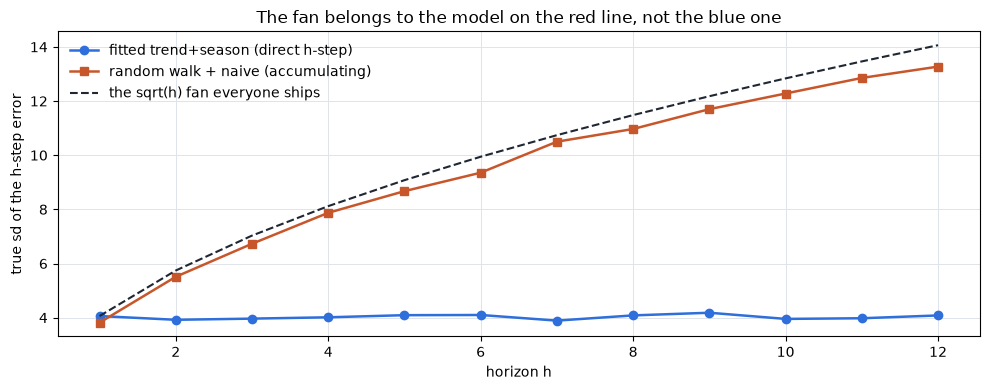

In [3]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(h, errs_fit.std(axis=0, ddof=1), color="#2f6fdb", marker="o", lw=1.8,
        label="fitted trend+season (direct h-step)")
ax.plot(h, errs_rw.std(axis=0, ddof=1), color="#c8562b", marker="s", lw=1.8,
        label="random walk + naive (accumulating)")
ax.plot(h, errs_fit.std(axis=0, ddof=1)[0] * np.sqrt(h), color="#1f2733", ls="--", lw=1.5,
        label="the sqrt(h) fan everyone ships")
ax.set_xlabel("horizon h"); ax.set_ylabel("true sd of the h-step error")
ax.set_title("The fan belongs to the model on the red line, not the blue one")
ax.grid(True, color="#dfe4ea", lw=0.7); ax.set_axisbelow(True); ax.legend(frameon=False)
plt.tight_layout(); plt.savefig("notebook_figure.png", dpi=140); plt.show()

## 3. The parameter-uncertainty term

The textbook regression interval is `s * sqrt(1 + x0'(X'X)^-1 x0)`. The second term is the
uncertainty in the fitted coefficients, and it grows as you forecast away from the training
window - the honest version of the fan section 2 just rejected. Dropping it is the single most
common way a band quietly stops keeping its claim.

In [4]:
print(f"{'train points':>13}{'leverage at h=12':>19}{'flat band':>12}{'+ param term':>14}{'width cost':>12}")
for n_train in (36, 60, 120, 240, 480):
    a = coverage_run(gaussian_flat, H, n_train, 800, np.random.default_rng(9))
    b = coverage_run(gaussian_theory, H, n_train, 800, np.random.default_rng(9))
    y, _ = make_series(np.random.default_rng(1), n_train + H)
    lev = float(leverage(fit_trend_season(y[:n_train]), H)[-1])
    print(f"{n_train:>13}{lev:>19.4f}{a['hits'][:, -1].mean():>12.3f}"
          f"{b['hits'][:, -1].mean():>14.3f}{b['width'].mean()/a['width'].mean():>11.2f}x")

 train points   leverage at h=12   flat band  + param term  width cost
           36             0.3079       0.906         0.939       1.12x
           60             0.1435       0.929         0.944       1.06x
          120             0.0597       0.955         0.968       1.03x
          240             0.0273       0.946         0.954       1.01x
          480             0.0131       0.943         0.945       1.01x


## 4. Conformal's guarantee is MARGINAL

Split conformal comes with a genuine finite-sample guarantee, and it keeps it. The question is
what the guarantee says: **marginal** coverage, averaged over everything - not coverage in the
situation the user is actually in.

Build a world with quiet and volatile blocks, with the **average variance held equal** to the
flat world, so nothing in the aggregate looks different. Then split the same intervals by the
regime the forecast landed in.

In [5]:
VOL = {"vol_period": 24, "vol_ratio": 9.0}
chk = make_series(np.random.default_rng(77), 40000, **VOL)[1]
base = make_series(np.random.default_rng(77), 40000)[1]
print(f"mean variance: regime world {np.mean(chk**2):.2f} vs flat world {np.mean(base**2):.2f}")
print()
print(f"{'method':<28}{'marginal':>10}{'in quiet':>10}{'in volatile':>13}{'spread':>9}")
for name in ("gaussian + parameter term", "split conformal", "rolling h-step quantile"):
    r = coverage_run(METHODS[name], H, N_TRAIN, 600, np.random.default_rng(23), CONF, **VOL)
    # split at the GEOMETRIC mid-point of the two sd levels: the median of a two-level array
    # lands ON a level, and a strict < then puts every point in one cell
    lo = r["sd"] < np.sqrt(r["sd"].min() * r["sd"].max())
    q, v = float(r["hits"][lo].mean()), float(r["hits"][~lo].mean())
    print(f"{name:<28}{r['hits'].mean():>10.3f}{q:>10.3f}{v:>13.3f}{q - v:>9.3f}")

mean variance: regime world 15.99 vs flat world 16.00

method                        marginal  in quiet  in volatile   spread
gaussian + parameter term        0.926     1.000        0.850    0.150
split conformal                  0.950     1.000        0.898    0.102
rolling h-step quantile          0.855     0.997        0.708    0.289


Conformal's marginal number lands on its promise almost exactly. In the quiet regime it covers
essentially everything; in the volatile regime - the only regime where anyone consults an
interval - it is materially short. **No marginal check can see this**, because the two errors
are constructed to cancel in the average. If you need the claim to hold where you stand, you
need a conditional method (normalise the scores by a volatility estimate) or a conditional
check.

## 5. Pointwise coverage is not path coverage

"95% band" means each point, separately. A planner reading a twelve-month fan usually wants the
whole path inside. Those are different claims, and how different depends on how correlated the
horizons are - measurable as `k_eff = log(path coverage) / log(pointwise coverage)`.

In [6]:
r = runs["gaussian + parameter term"]
point, path = float(r["hits"].mean()), float(r["hits"].all(axis=1).mean())
print(f"pointwise coverage                    {point:.3f}")
print(f"whole-path coverage (all {H} inside)    {path:.3f}   <- the number a planner needs")
print(f"if the horizons were independent      {point ** H:.3f}")
print()
print(f"{'rho':>6}{'pointwise':>12}{'path':>9}{'k_eff of the 12 horizons':>28}")
for rho in (0.0, 0.4, 0.7, 0.9):
    rr = coverage_run(gaussian_theory, H, N_TRAIN, 500, np.random.default_rng(33), CONF, rho=rho)
    pt, pa = float(rr["hits"].mean()), float(rr["hits"].all(axis=1).mean())
    print(f"{rho:>6.1f}{pt:>12.3f}{pa:>9.3f}{np.log(pa)/np.log(pt):>28.2f}")

pointwise coverage                    0.948
whole-path coverage (all 12 inside)    0.535   <- the number a planner needs
if the horizons were independent      0.525

   rho   pointwise     path    k_eff of the 12 horizons
   0.0       0.951    0.560                       11.50
   0.4       0.945    0.552                       10.50
   0.7       0.932    0.598                        7.26
   0.9       0.890    0.626                        4.01


## 6. The check itself

Every failure above is detectable in principle by measuring coverage. The reason they survive
in practice is that the check people run has almost no power - and the test points a backtest
supplies are not independent (Day 172 measured twenty rolling windows stepped by 1 to be worth
about **one**).

In [7]:
from math import erf, sqrt

def coverage_check_power(true_cov, nominal, m, k_eff_ratio=1.0, alpha=0.05):
    """One-sided binomial check that coverage is below nominal, at m points of which
    k_eff_ratio are independent."""
    m_eff = max(1.0, m * k_eff_ratio)
    se0, se1 = sqrt(nominal*(1-nominal)/m_eff), sqrt(true_cov*(1-true_cov)/m_eff)
    crit = nominal - 1.6448536269514722 * se0
    return float(0.5 * (1 + erf((crit - true_cov) / (se1 * sqrt(2)))))

print("power to catch a nominally 95% band that really covers 90%:")
print()
print(f"{'test points':>13}{'independent':>15}{'k_eff=1/12':>14}{'k_eff=1/20':>14}")
for m in (20, 50, 100, 250, 500, 1000, 5000):
    print(f"{m:>13}{coverage_check_power(0.90, 0.95, m):>15.3f}"
          f"{coverage_check_power(0.90, 0.95, m, 1/12):>14.3f}"
          f"{coverage_check_power(0.90, 0.95, m, 1/20):>14.3f}")

power to catch a nominally 95% band that really covers 90%:

  test points    independent    k_eff=1/12    k_eff=1/20
           20          0.326         0.164         0.152
           50          0.493         0.196         0.176
          100          0.681         0.238         0.205
          250          0.925         0.332         0.272
          500          0.994         0.453         0.359
         1000          1.000         0.628         0.493
         5000          1.000         0.986         0.925


A validation run on twenty backtest windows has a **0.15** chance of noticing that a 95% band
is really a 90% one. "We validated the intervals" is usually a sentence about a check with no
power, which is exactly why bad bands survive.

## 7. Try your own

In [8]:
# # Your own interval method: (y_train, h, conf) -> (lo, hi).
# def my_band(y, h, conf=CONF, **kw):
#     fit = fit_trend_season(y)
#     p = predict(fit, h)
#     w = Z[conf] * np.sqrt(fit["s2"] * (1.0 + leverage(fit, h)))
#     scale = np.std(fit["resid"][-24:]) / np.sqrt(fit["s2"])   # recent-volatility scaling
#     return p - w * scale, p + w * scale
# r = coverage_run(my_band, H, N_TRAIN, 600, np.random.default_rng(3), CONF,
#                  vol_period=24, vol_ratio=9.0)
# lo = r["sd"] < np.sqrt(r["sd"].min() * r["sd"].max())
# print(f"marginal {r['hits'].mean():.3f}  quiet {r['hits'][lo].mean():.3f}  "
#       f"volatile {r['hits'][~lo].mean():.3f}  width {r['width'].mean():.2f}")

## What this build measured

| Finding | Number |
|---|---|
| The shipped sqrt(h) band's coverage / width | 0.994 at 2.71x the narrowest honest band |
| Fitted error-growth exponent, direct trend+season fit | +0.010 (the fan claims +0.5) |
| Fitted error-growth exponent, random walk + naive | +0.519 |
| Flat band at 36 training points, h=12 | 0.896 coverage |
| Same band + the parameter term | 0.937, at 1.12x the width |
| Split conformal in a two-regime world | marginal 0.950, quiet 1.000, volatile 0.898 |
| Rolling h-step quantile, same world | marginal 0.855, volatile 0.708 |
| Pointwise 0.948 becomes whole-path | 0.535 |
| k_eff of 12 horizons, rho 0 -> 0.9 | 11.4 -> 4.1 |
| Per-point shortfall at nominal 99% | 0.0024, compounding to 0.025 on the path |
| Power to catch a 90%-not-95% band on 20 backtest windows | 0.152 |
| Best method by interval score | gaussian + parameter term |

**The full build:**
- `python evidence.py` - the eight-section measurement, ~20s
- `python -m pytest` - 24 assertions, including a diff of this notebook against the library
- `streamlit run app.py` - build a band, then measure whether its claim holds where you stand
- `python make_chart.py` - the four-panel audit figure

**Reading, for the results this build re-derives rather than cites:** Hyndman & Athanasopoulos,
*Forecasting: Principles and Practice*, on prediction intervals and why published ones are too
narrow; Gneiting & Raftery (2007) on proper scoring rules and the interval score; Vovk et al.
and Lei et al. (2018) on conformal prediction and its marginal guarantee; Romano, Patterson &
Candes (2019) on conditionally-valid conformal intervals; Chatfield (1993) on calculating
interval forecasts.

[Back to the portfolio index](https://github.com/phoebefu6/phoebe-the-builder)